In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import ttest_ind

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("data/zomato.csv", encoding="latin1")
df.columns = df.columns.str.strip()

df = df.rename(columns={
    "Latitude": "lat",
    "Longitude": "lon",
    "Aggregate rating": "rating",
    "Votes": "votes",
    "Average Cost for two": "cost"
})
print(df.shape)
df.head()

(9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,lon,lat,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,rating,Rating color,Rating text,votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
cities = df["City"].dropna().unique()

g_cities = [c for c in cities if str(c).startswith("G")]

print(g_cities)

['Gainesville', 'Ghaziabad', 'Goa', 'Gurgaon', 'Guwahati']


In [4]:

city = "Ghaziabad"   # change as needed

df = df[df["City"] == city].copy()
df = df.dropna(subset=["lat", "lon"])

print("Total data points:", len(df))

Total data points: 25


In [6]:
# Convert to numeric safely
for col in ["votes", "rating", "cost"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Fill missing values (NO inplace)
df["votes"] = df["votes"].fillna(df["votes"].median())
df["rating"] = df["rating"].fillna(df["rating"].median())
df["cost"] = df["cost"].fillna(df["cost"].median())

# Drop missing coordinates
df = df.dropna(subset=["lat", "lon"])

# Remove outliers
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

for col in ["votes", "cost"]:
    df = remove_outliers(df, col)

print("After cleaning:", df.shape)

After cleaning: (22, 21)


In [7]:
df["population"] = np.log1p(df["votes"])
df["traffic"] = df["rating"] * 20
df["rent"] = np.log1p(df["cost"])
df["competition"] = df.groupby(["City", "Locality"])["Locality"].transform("count")

def norm(x):
    return (x - x.min()) / (x.max() - x.min()) if x.max()!=x.min() else 0

# Normalize per city (IMPORTANT)
df["pop_n"] = df.groupby("City")["population"].transform(norm)
df["traffic_n"] = df.groupby("City")["traffic"].transform(norm)
df["rent_n"] = df.groupby("City")["rent"].transform(norm)
df["comp_n"] = df.groupby("City")["competition"].transform(norm)

# Final score
df["score"] = (
    0.3 * df["pop_n"] +
    0.3 * df["traffic_n"] -
    0.2 * df["rent_n"] -
    0.2 * df["comp_n"]
)

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,lon,lat,Cuisines,...,votes,population,traffic,rent,competition,pop_n,traffic_n,rent_n,comp_n,score
1116,309757,Chaudhary Ke Mashhoor Paranthe,1,Ghaziabad,"MB 48, Shipra Suncity, Indirapuram, Ghaziabad",Indirapuram,"Indirapuram, Ghaziabad",77.374442,28.636014,North Indian,...,14,2.708050,56.0,5.017280,5,0.467468,0.717949,0.207578,0.307692,0.252571
1117,307903,Thakur Bakers,1,Ghaziabad,"Shop 24, Regalia Heights, Shipra Suncity, Indi...",Indirapuram,"Indirapuram, Ghaziabad",77.374192,28.636022,Bakery,...,6,1.945910,60.0,5.017280,5,0.335906,0.769231,0.207578,0.307692,0.228487
1118,313502,FoodByMom,1,Ghaziabad,"Near Shipra Mall, Indirapuram, Ghaziabad",Indirapuram,"Indirapuram, Ghaziabad",77.369326,28.635083,North Indian,...,161,5.087596,72.0,5.707110,5,0.878230,0.923077,0.563640,0.307692,0.366125
1119,18409175,Mr. Brown,1,Ghaziabad,"C-1, Saya Zenith, Next to CISF Camp, Opposite ...",Indirapuram,"Indirapuram, Ghaziabad",77.378751,28.637449,"Fast Food, Cafe, Desserts, Bakery",...,52,3.970292,78.0,6.216606,5,0.685359,1.000000,0.826621,0.307692,0.278745
1120,18456342,Mitalis Kitchen,1,Ghaziabad,"Mall Road, Ahinsha Khand ll, Near Shanti Gopal...",Indirapuram,"Indirapuram, Ghaziabad",77.315483,28.638238,North Indian,...,1,0.693147,0.0,5.860786,5,0.119652,0.000000,0.642962,0.307692,-0.154235


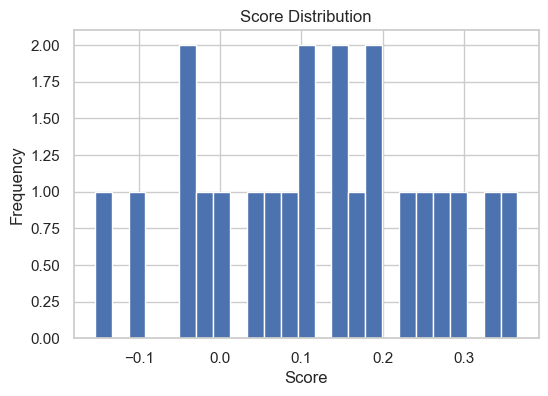

In [8]:
#Histogram
plt.figure(figsize=(6,4))
plt.hist(df["score"], bins=25)
plt.title("Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

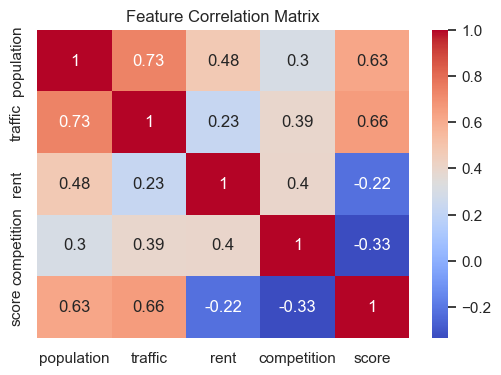

In [9]:
#Correlation heatmap
cols = ["population", "traffic", "rent", "competition", "score"]

plt.figure(figsize=(6,4))
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
#Clustering
features = df[["lat","lon","population","traffic","rent","competition"]]

scaler = MinMaxScaler()
X = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X)

df.head()

In [ ]:
#Best global location
cluster_df = df.groupby("cluster").agg({
    "lat":"mean",
    "lon":"mean",
    "score":"mean"
}).reset_index()

best = cluster_df.loc[cluster_df["score"].idxmax()]

print("🌍 Best Location (Global):")
print("Latitude:", round(best["lat"], 5))
print("Longitude:", round(best["lon"], 5))
print("Score:", round(best["score"], 3))

In [ ]:
#Hypothesis testing
high = df[df["traffic"] > df["traffic"].median()].copy()
low = df[df["traffic"] <= df["traffic"].median()].copy()

t_stat, p_val = ttest_ind(high["score"], low["score"])

print("T-statistic:", round(t_stat,4))
print("P-value:", round(p_val,5))

if p_val < 0.05:
    print("Result: Significant difference")
else:
    print("Result: Not significant")

In [ ]:
#Boxplot
high["group"] = "High Traffic"
low["group"] = "Low Traffic"

combined = pd.concat([high, low])

plt.figure(figsize=(6,4))
sns.boxplot(x="group", y="score", data=combined)
plt.title("Score Comparison (High vs Low Traffic)")
plt.show()

In [ ]:
#Denisty plot
plt.figure(figsize=(6,4))
sns.kdeplot(high["score"], label="High Traffic", fill=True)
sns.kdeplot(low["score"], label="Low Traffic", fill=True)
plt.legend()
plt.title("Score Density Distribution")
plt.show()

In [ ]:
#Mean comparison
means = [high["score"].mean(), low["score"].mean()]

plt.figure(figsize=(5,3))
plt.bar(["High Traffic","Low Traffic"], means)
plt.title("Mean Score Comparison")
plt.show()